# Rate Change Analysis

Convergence of `iat_estimate` after mid-transfer rate changes (gradual sequence), plus throughput, RTT, retransmissions, and ACK count per rate segment. Compares Default, α=2.0, α=3.0, and α=5.0 kernels.

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor
from functools import partial
# from sklearn.cluster import KMeans

In [2]:
PLOT_COLORS = ("#1f77b4", "#ff7f0e", "#2ca02c", "#AA4A44", "#CBC3E3")
FONT_SIZES = {"small": 18, "medium": 24, "large": 28}

matplotlib.rcParams.update(
    {
        "figure.figsize": (16, 10),
        "figure.titlesize": FONT_SIZES["large"],
        "font.size": FONT_SIZES["small"],
        "axes.labelsize": FONT_SIZES["medium"],
        "axes.titlesize": FONT_SIZES["medium"],
        "xtick.labelsize": FONT_SIZES["small"],
        "ytick.labelsize": FONT_SIZES["small"],
        "legend.fontsize": FONT_SIZES["small"],
    }
)

## Config

In [3]:
@dataclass(frozen=True)
class Config:
    root: Path
    rate_map: dict
    test_plan: dict
    phy_rates: dict
    kernels: tuple
    iterations: int
    sequence: list
    duration_per_rate: float

    @property
    def rates(self) -> tuple:
        return tuple(self.test_plan.keys())

    @property
    def delays(self) -> tuple:
        return tuple(dict.fromkeys(
            delay for cases in self.test_plan.values() for _, delay in cases
        ))

    @property
    def conditions(self) -> list[tuple]:
        return [
            (r, bw, delay, i)
            for r, cases in self.test_plan.items()
            for bw, delay in cases
            for i in range(1, self.iterations + 1)
        ]

    def get_rate_name(self, rate: int) -> str:
        return self.rate_map.get(rate, f"Rate{rate}")

    def base(self, rate, bw, delay, iteration):
        return f"rate{rate}_bw{bw}_delay{delay}_iter{iteration}"

    def dmesg_path(self, kernel, rate, bw, delay, iteration):
        return (
            self.root
            / kernel
            / "dmesg"
            / f"{self.base(rate, bw, delay, iteration)}.txt"
        )

    def raw_path(self, kernel, rate, bw, delay, iteration):
        return (
            self.root / kernel / "raw" /
            f"{self.base(rate, bw, delay, iteration)}.json"
        )

    def debug_log_path(self, kernel, rate, bw, delay):
        return (self.root / kernel / "logs" /
                f"rate{rate}_bw{bw}_delay{delay}.log")

    def log_path(self, kernel):
        return (self.root / kernel / "session.log")

    def rc_raw_path(self, kernel, iteration):
        return self.root / kernel / "raw" / f"ratechange_bwnolim_delaynodelay_iter{iteration}.json"

    def rc_dmesg_path(self, kernel, iteration):
        return self.root / kernel / "dmesg" / f"ratechange_bwnolim_delaynodelay_iter{iteration}.txt"

    def rc_rates_path(self, kernel, iteration):
        return self.root / kernel / "logs" / f"ratechange_bwnolim_delaynodelay_iter{iteration}_rates.log"


config = Config(
    root=Path("../results/rate_change_test/").resolve(),
    rate_map={
        67: "HT20-SGI-MCS3",
        71: "HT20-SGI-MCS7",
        199: "HT40-SGI-MCS7",
        214: "HT40-SGI-MCS14",
    },
    phy_rates={
        67: 28.9,
        71: 72.2,
        199: 150.0,
        214: 270.0,
    },
    test_plan={
        67: [("nolim", "nodelay"),],
        71: [("nolim", "nodelay"),],
        199: [("nolim", "nodelay"),],
        214: [("nolim", "nodelay"),],
    },
    kernels=("default", "tcpaad_20", "tcpaad_30", "tcpaad_50"),
    iterations=5,
    sequence=[67, 71, 199, 214, 199, 71, 67],
    duration_per_rate=4.5,
)

print("Project root:", config.root, config.root.exists())

Project root: /home/rakhat/ghq/github.com/4ry1337/TCP-AAD-Tests/results/rate_change_test True


## Parse functions

In [4]:
_RECV_RE = re.compile(
    r'^(\S+).*TCP_AAD RECV '
    r'sk=(?P<sk>\S+).*'
    r'UPDATE.*iat_estimate=(?P<iat_estimate>\d+)'
    r'.*ato_us=(?P<ato_us>\d+)'
)
_ACK_SENT_RE = re.compile(r'^(\S+).*?(?:TCP_AAD|TCP_DACK) ACK_SENT sk=(\S+)')
_RATE_LOG_RE = re.compile(
    r'^(\S+)\s+RATE_CHANGE\s+rate_idx=(\d+)\s+name=(\S+)(?:\s+(.*))?$'
)


def _parse_ts(ts_str: str) -> datetime:
    ts_str = re.sub(r',(\d+)([+-]\d{2}:\d{2})', r'.\1\2', ts_str)
    ts_str = ts_str.replace('T', ' ')
    for fmt in ('%Y-%m-%d %H:%M:%S.%f%z', '%Y-%m-%d %H:%M:%S%z'):
        try:
            return datetime.strptime(ts_str, fmt)
        except ValueError:
            continue
    raise ValueError(f'Unparsable timestamp: {ts_str!r}')


def parse_dmesg(path: Path, kernel: str, iteration: int) -> pd.DataFrame:
    """Extract TCP_AAD RECV UPDATE rows (tcpaad kernels only)."""
    rows = []
    with open(path) as f:
        for line in f:
            if 'TCP_AAD RECV' not in line or 'UPDATE' not in line:
                continue
            m = _RECV_RE.match(line.strip())
            if not m:
                continue
            try:
                ts = _parse_ts(m.group(1))
            except ValueError:
                continue
            rows.append({
                'ts':           ts,
                'sk':           m.group('sk'),
                'iat_estimate': int(m.group('iat_estimate')),
                'ato_us':       int(m.group('ato_us')),
                'kernel':       kernel,
                'iteration':    iteration,
            })
    return pd.DataFrame(rows)


def parse_ack_sent(path: Path, kernel: str, iteration: int) -> pd.DataFrame:
    """Collect ACK_SENT events from dmesg (both TCP_AAD and TCP_DACK)."""
    rows = []
    with open(path) as f:
        for line in f:
            if 'ACK_SENT' not in line:
                continue
            m = _ACK_SENT_RE.match(line.strip())
            if not m:
                continue
            try:
                ts = _parse_ts(m.group(1))
            except ValueError:
                continue
            rows.append({'ts': ts, 'sk': m.group(2), 'kernel': kernel, 'iteration': iteration})
    return pd.DataFrame(rows)


def parse_rates_log(path: Path) -> pd.DataFrame:
    rows = []
    with open(path) as f:
        for line in f:
            m = _RATE_LOG_RE.match(line.strip())
            if not m:
                continue
            ts_str, rate_idx, rate_name, extra = m.groups()
            is_initial = bool(extra and 'INITIAL' in extra)
            if is_initial and rows:
                break
            try:
                ts = _parse_ts(ts_str)
            except ValueError:
                continue
            rows.append({
                'ts':         ts,
                'rate_idx':   int(rate_idx),
                'rate_name':  rate_name,
                'is_initial': is_initial,
            })
    return pd.DataFrame(rows)


def parse_iperf3(path: Path, kernel: str, iteration: int):
    """Return (summary dict, intervals DataFrame) from iperf3 JSON."""
    with open(path) as f:
        d = json.load(f)
    sender = d['end']['streams'][0]['sender']
    summary = {
        'kernel':          kernel,
        'iteration':       iteration,
        'bits_per_second': sender['bits_per_second'],
        'retransmits':     sender.get('retransmits', 0),
        'mean_rtt_us':     sender.get('mean_rtt', 0),
        'start_secs':      d['start']['timestamp']['timesecs'],
    }
    rows = []
    for iv in d['intervals']:
        s = iv['streams'][0]
        if s.get('omitted'):
            continue
        rows.append({
            'kernel':      kernel,
            'iteration':   iteration,
            't_start':     s['start'],
            't_end':       s['end'],
            't_mid':       (s['start'] + s['end']) / 2,
            'mbps':        s['bits_per_second'] / 1e6,
            'rtt_us':      s.get('rtt', 0),
            'retransmits': s.get('retransmits', 0),
            'snd_cwnd':    s.get('snd_cwnd', 0),
        })
    return summary, pd.DataFrame(rows)

## Load data

In [5]:
recv_data  = {}  # (kernel, iteration) -> DataFrame  [tcpaad kernels only]
ack_data   = {}  # (kernel, iteration) -> DataFrame
rates_data = {}  # (kernel, iteration) -> DataFrame
perf_summ  = {}  # (kernel, iteration) -> dict
perf_ivals = {}  # (kernel, iteration) -> DataFrame

missing = []
for kernel in config.kernels:
    for it in range(1, config.iterations + 1):
        raw_path   = config.rc_raw_path(kernel, it)
        dmesg_path = config.rc_dmesg_path(kernel, it)
        rates_path = config.rc_rates_path(kernel, it)

        if not raw_path.exists():
            missing.append(str(raw_path))
            continue

        summ, ivals = parse_iperf3(raw_path, kernel, it)
        perf_summ[(kernel, it)]  = summ
        perf_ivals[(kernel, it)] = ivals

        if rates_path.exists():
            rates_data[(kernel, it)] = parse_rates_log(rates_path)

        if dmesg_path.exists():
            if kernel != "default":
                recv_data[(kernel, it)] = parse_dmesg(dmesg_path, kernel, it)
            ack_data[(kernel, it)] = parse_ack_sent(dmesg_path, kernel, it)

if missing:
    print(f"Missing {len(missing)} files:")
    for p in missing:
        print(" ", p)
else:
    print("All files loaded.")
print(f"iperf3: {len(perf_summ)}, ack: {len(ack_data)}, recv: {len(recv_data)}, rates: {len(rates_data)}")

All files loaded.
iperf3: 20, ack: 20, recv: 15, rates: 20


In [6]:
KERNEL_LABELS = {"default": "Default", "tcpaad_20": "α=2.0", "tcpaad_30": "α=3.0", "tcpaad_50": "α=5.0"}
TCPAAD_KERNELS = [k for k in config.kernels if k != "default"]

seen, RATE_ORDER = set(), []
for r in config.sequence:
    if r not in seen:
        RATE_ORDER.append(r)
        seen.add(r)
RATE_NAMES = [config.get_rate_name(r) for r in RATE_ORDER]

RATE_COLORS = {67: "#e8f4fd", 71: "#fef3e8", 199: "#eafaea", 214: "#fdeaea"}

# Theoretical intra-burst gap at each PHY rate (µs): segment_size_bits / phy_rate_bps
# 1448 byte segments: HT20-SGI-MCS3=28.9M, HT20-SGI-MCS7=72.2M, HT40-SGI-MCS7=150M, HT40-SGI-MCS14=270M
EXPECTED_IAT = {
    67:  int(1448 * 8 / 28.9e6 * 1e6),   # ~401 µs
    71:  int(1448 * 8 / 72.2e6 * 1e6),   # ~160 µs
    199: int(1448 * 8 / 150.0e6 * 1e6),  # ~77 µs
    214: int(1448 * 8 / 270.0e6 * 1e6),  # ~43 µs
}

plot_dir = Path("tmp")
plot_dir.mkdir(exist_ok=True)


def get_main_sk(df):
    return df["sk"].value_counts().idxmax()


def to_rel_secs(series, ref_ts):
    return series.apply(lambda t: (t - ref_ts).total_seconds())


def downsample_by_change(df, col="iat_estimate"):
    return df[df[col].ne(df[col].shift())].reset_index(drop=True)


def rate_segments(df_rates, total_duration):
    ref = df_rates["ts"].iloc[0]
    events = [(0.0, df_rates["rate_idx"].iloc[0])]
    for _, row in df_rates.iloc[1:].iterrows():
        events.append(((row["ts"] - ref).total_seconds(), row["rate_idx"]))
    segs = []
    for i, (t_start, rate_idx) in enumerate(events):
        t_end = events[i + 1][0] if i + 1 < len(events) else total_duration
        segs.append((t_start, t_end, rate_idx))
    return segs


def assign_segments(df_ivals, segs):
    df = df_ivals.copy()
    df["rate_idx"] = None
    df["rate_name"] = None
    for t_start, t_end, rate_idx in segs:
        mask = (df["t_mid"] >= t_start) & (df["t_mid"] < t_end)
        df.loc[mask, "rate_idx"] = rate_idx
        df.loc[mask, "rate_name"] = config.get_rate_name(rate_idx)
    return df


segs_by_key = {}
for kernel in config.kernels:
    for it in range(1, config.iterations + 1):
        key = (kernel, it)
        if key not in perf_ivals or key not in rates_data:
            continue
        total = perf_ivals[key]["t_end"].max()
        segs = rate_segments(rates_data[key], total)
        segs_by_key[key] = segs
        perf_ivals[key] = assign_segments(perf_ivals[key], segs)


## iat_estimate over time

Gradual sequence. Each subplot shows one α value; all 5 iterations are overlaid. Default kernel has no TCP_AAD logs and is omitted here.

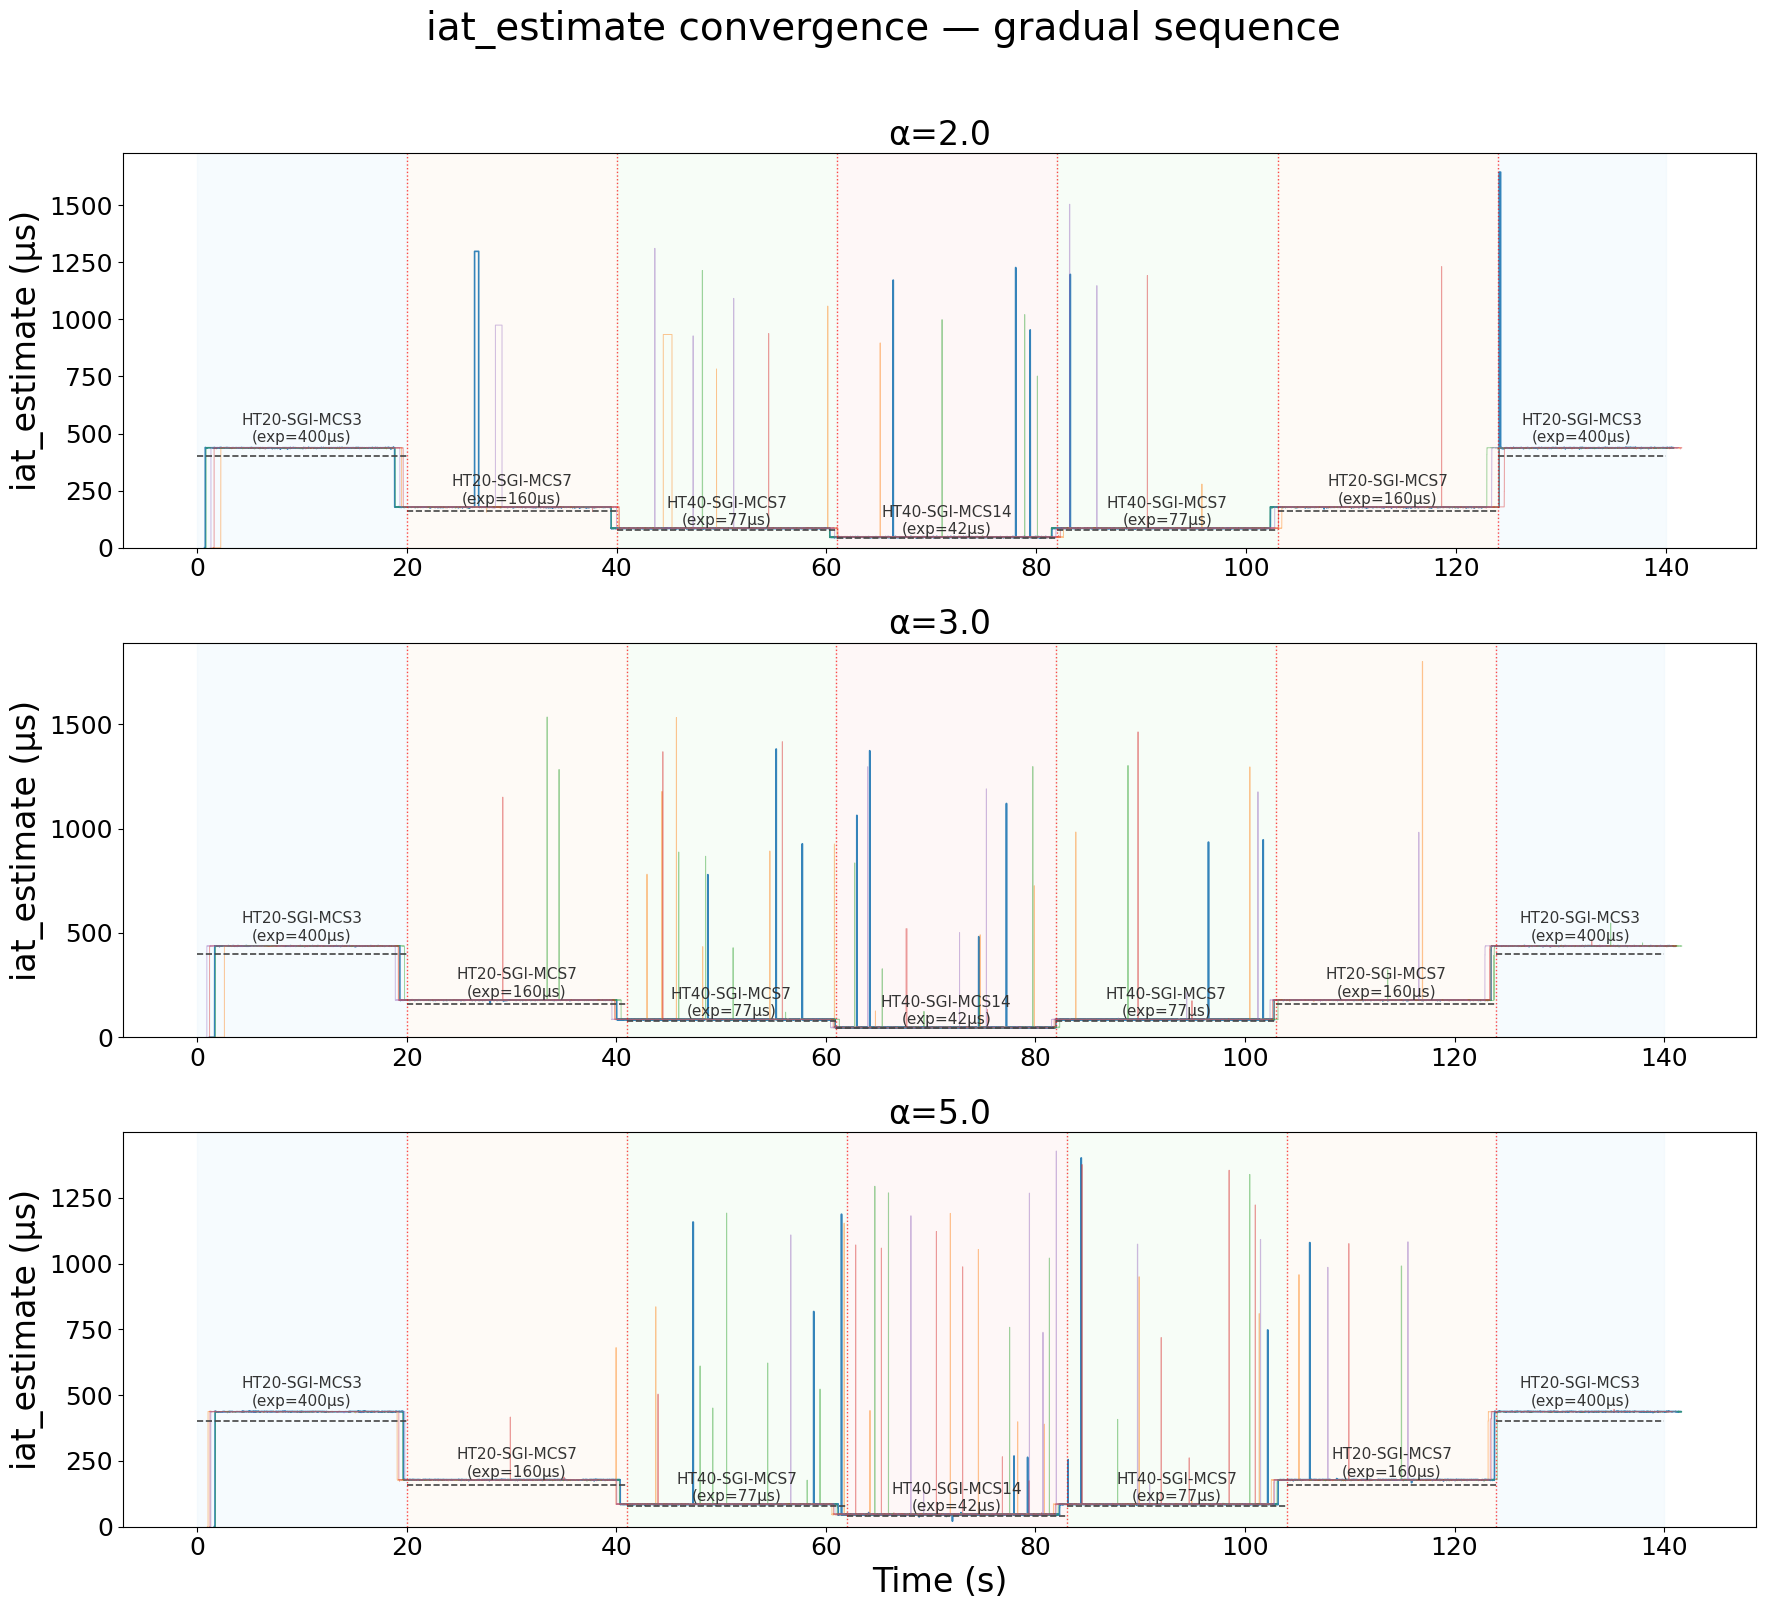

In [7]:
fig, axes = plt.subplots(len(TCPAAD_KERNELS), 1, figsize=(18, 16), sharex=False)
fig.suptitle("iat_estimate convergence — gradual sequence", y=1.01)

for ax, kernel in zip(axes, TCPAAD_KERNELS):
    for it in range(1, config.iterations + 1):
        key = (kernel, it)
        if key not in recv_data or key not in rates_data:
            continue
        df_recv = recv_data[key]
        df_rates = rates_data[key]
        if df_recv.empty:
            continue
        main_sk = get_main_sk(df_recv)
        df_main = df_recv[df_recv["sk"] == main_sk].copy()
        ref_ts = df_rates["ts"].iloc[0]
        df_main["t_s"] = to_rel_secs(df_main["ts"], ref_ts)
        df_main = downsample_by_change(df_main)
        lw = 1.2 if it == 1 else 0.7
        alp = 0.9 if it == 1 else 0.45
        ax.step(df_main["t_s"], df_main["iat_estimate"], where="post", linewidth=lw, alpha=alp)

    key1 = (kernel, 1)
    if key1 in segs_by_key:
        for t_start, t_end, rate_idx in segs_by_key[key1]:
            ax.axvspan(t_start, t_end, color=RATE_COLORS.get(rate_idx, "#f9f9f9"), alpha=0.35, zorder=0)
            exp = EXPECTED_IAT.get(rate_idx, 0)
            ax.hlines(exp, t_start, t_end, colors="#444", linewidths=1.2, linestyles="--", zorder=2)
            ax.text((t_start + t_end) / 2, exp * 1.12,
                    f"{config.get_rate_name(rate_idx)}\n(exp={exp}µs)",
                    ha="center", va="bottom", fontsize=11, color="#333", zorder=3)
        for t_start, _, _ in segs_by_key[key1][1:]:
            ax.axvline(t_start, color="red", linewidth=1.0, linestyle=":", alpha=0.7)

    ax.set_ylabel("iat_estimate (µs)")
    ax.set_title(KERNEL_LABELS[kernel])
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig(plot_dir / "iat_estimate_gradual.png", dpi=150, bbox_inches="tight")
plt.show()


## Per-run metrics

Throughput, RTT, and retransmission timelines for each kernel. All 5 iterations overlaid; background shading marks rate segments.

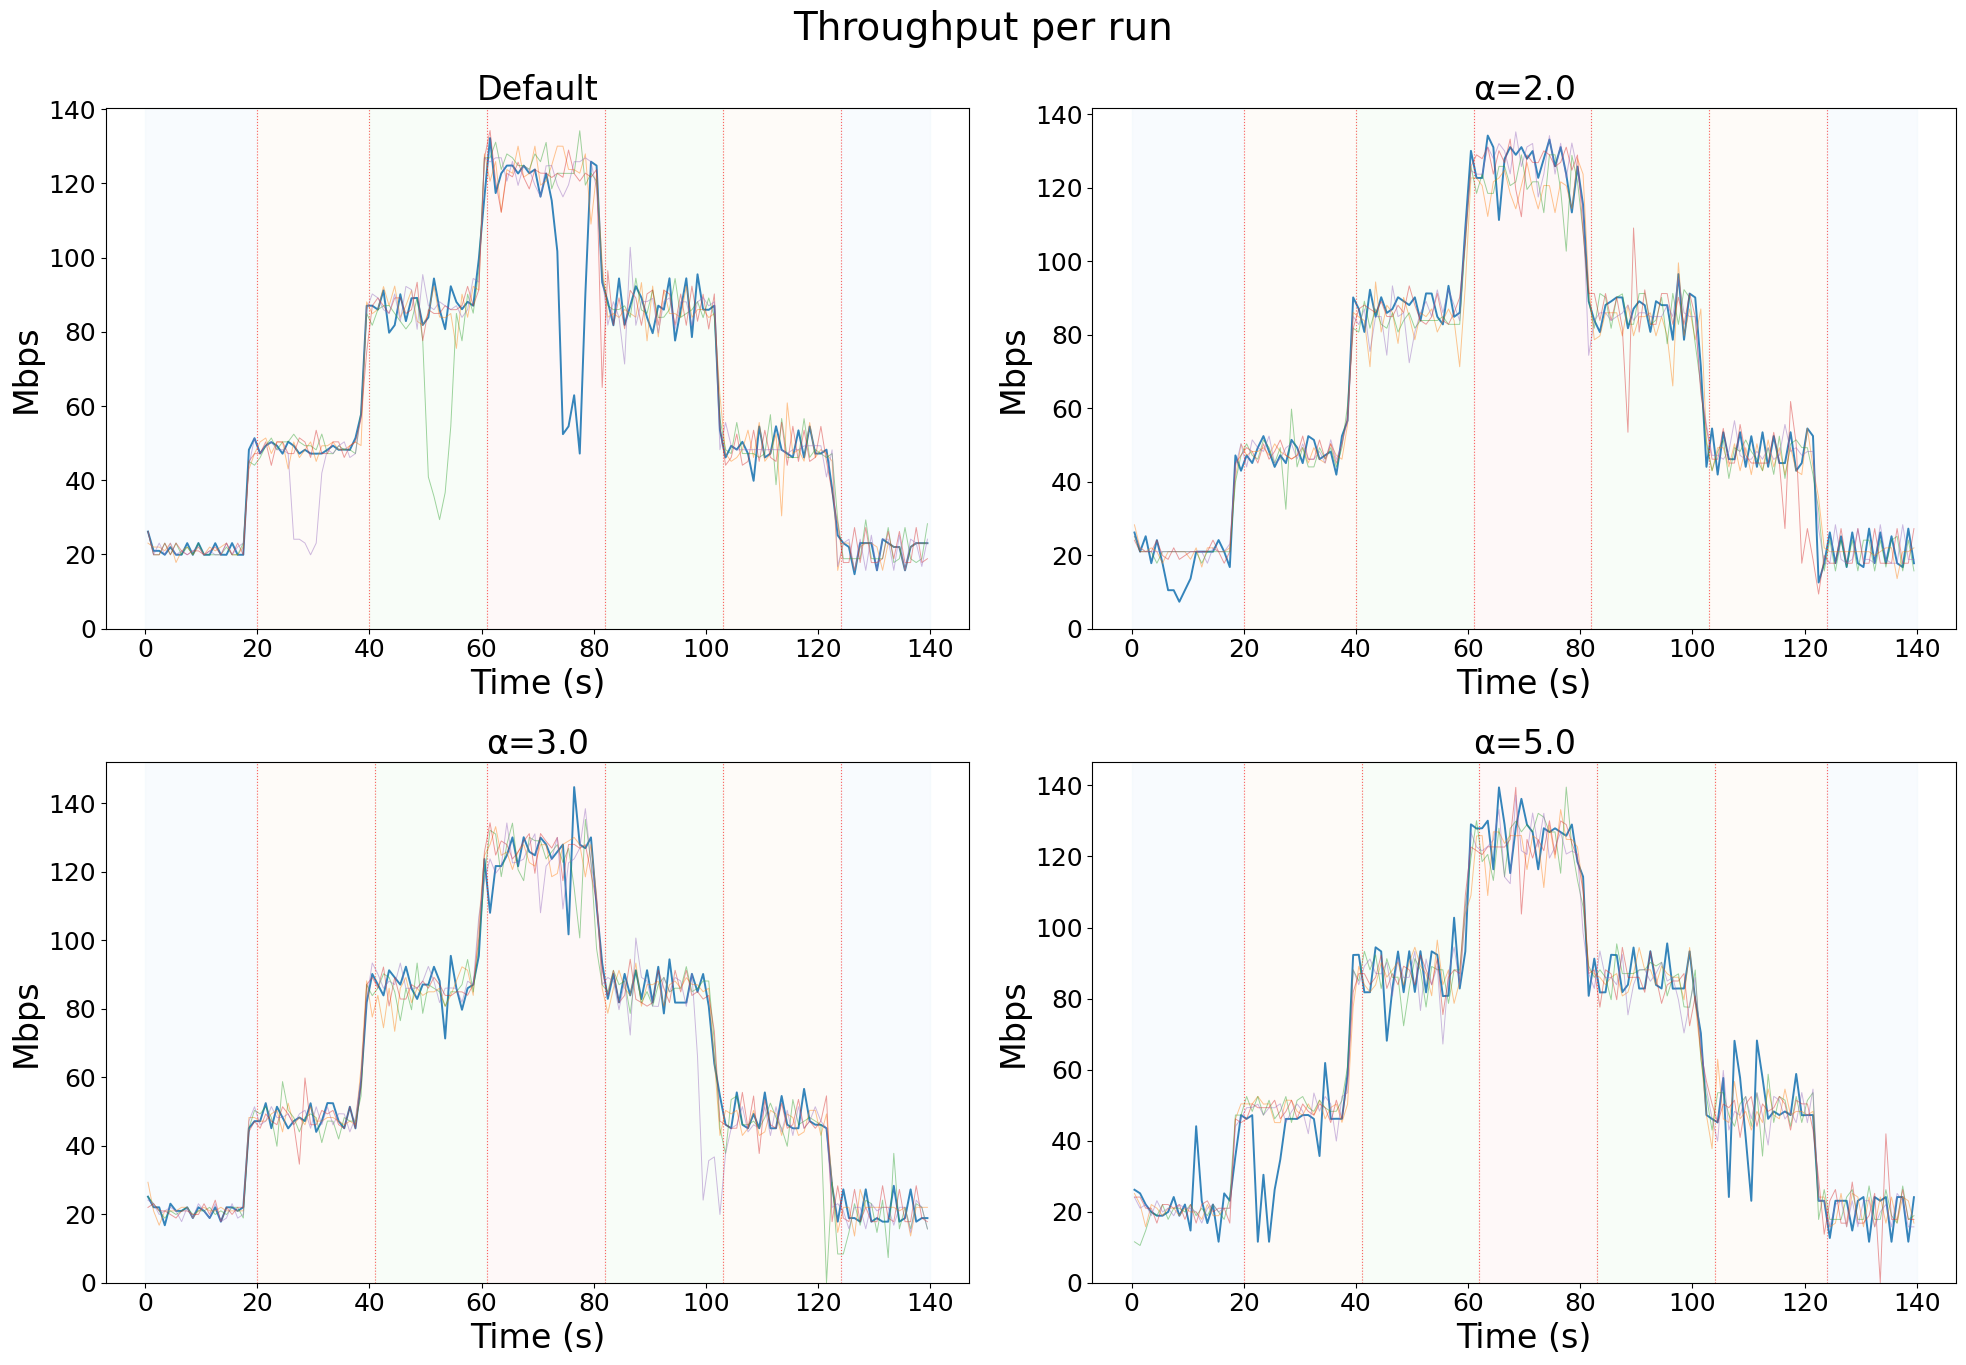

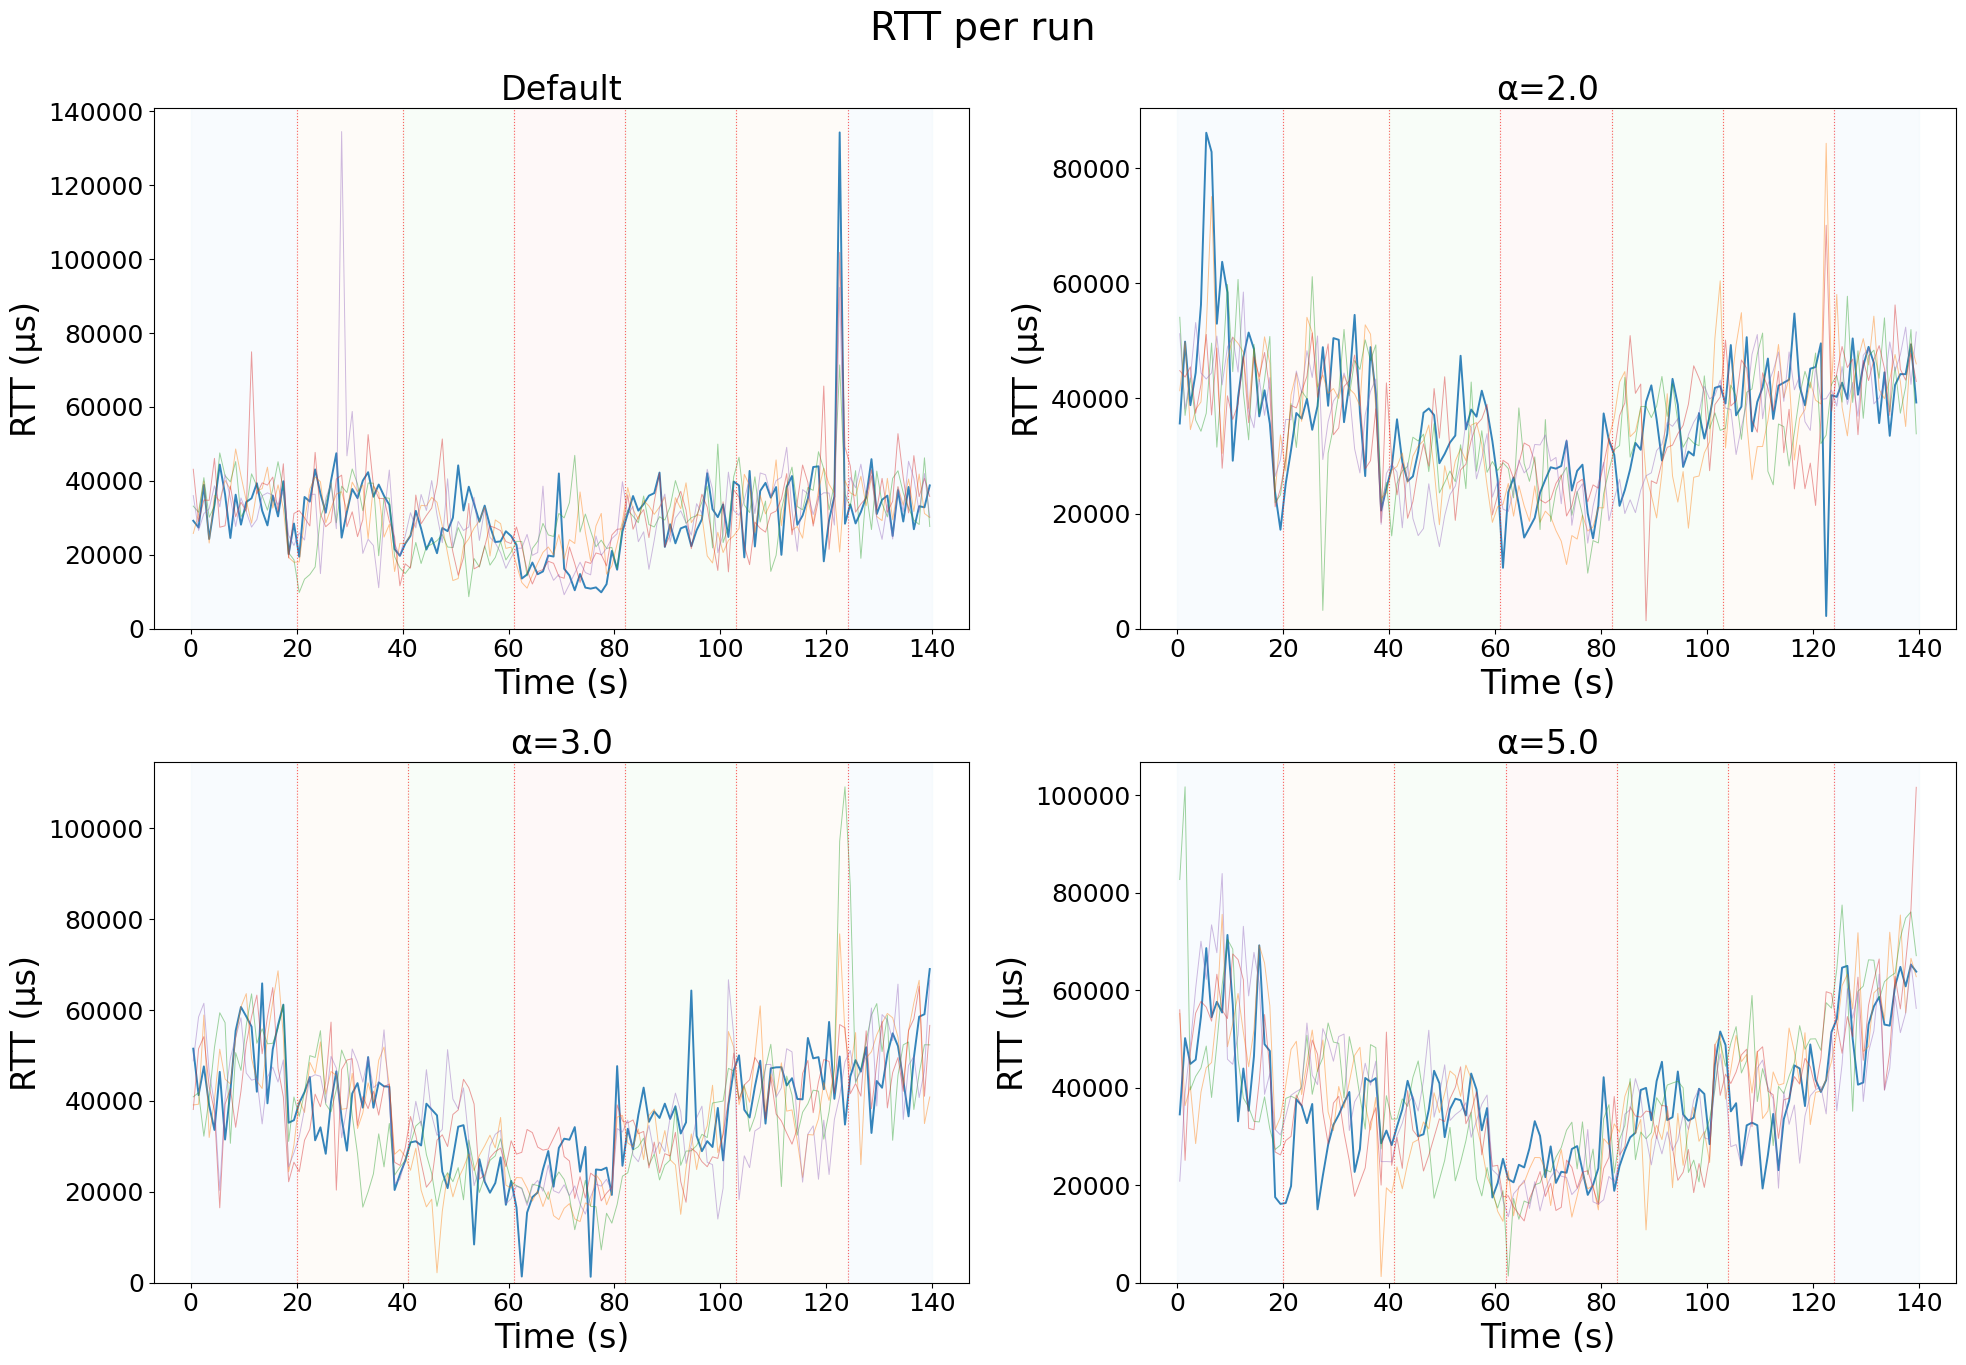

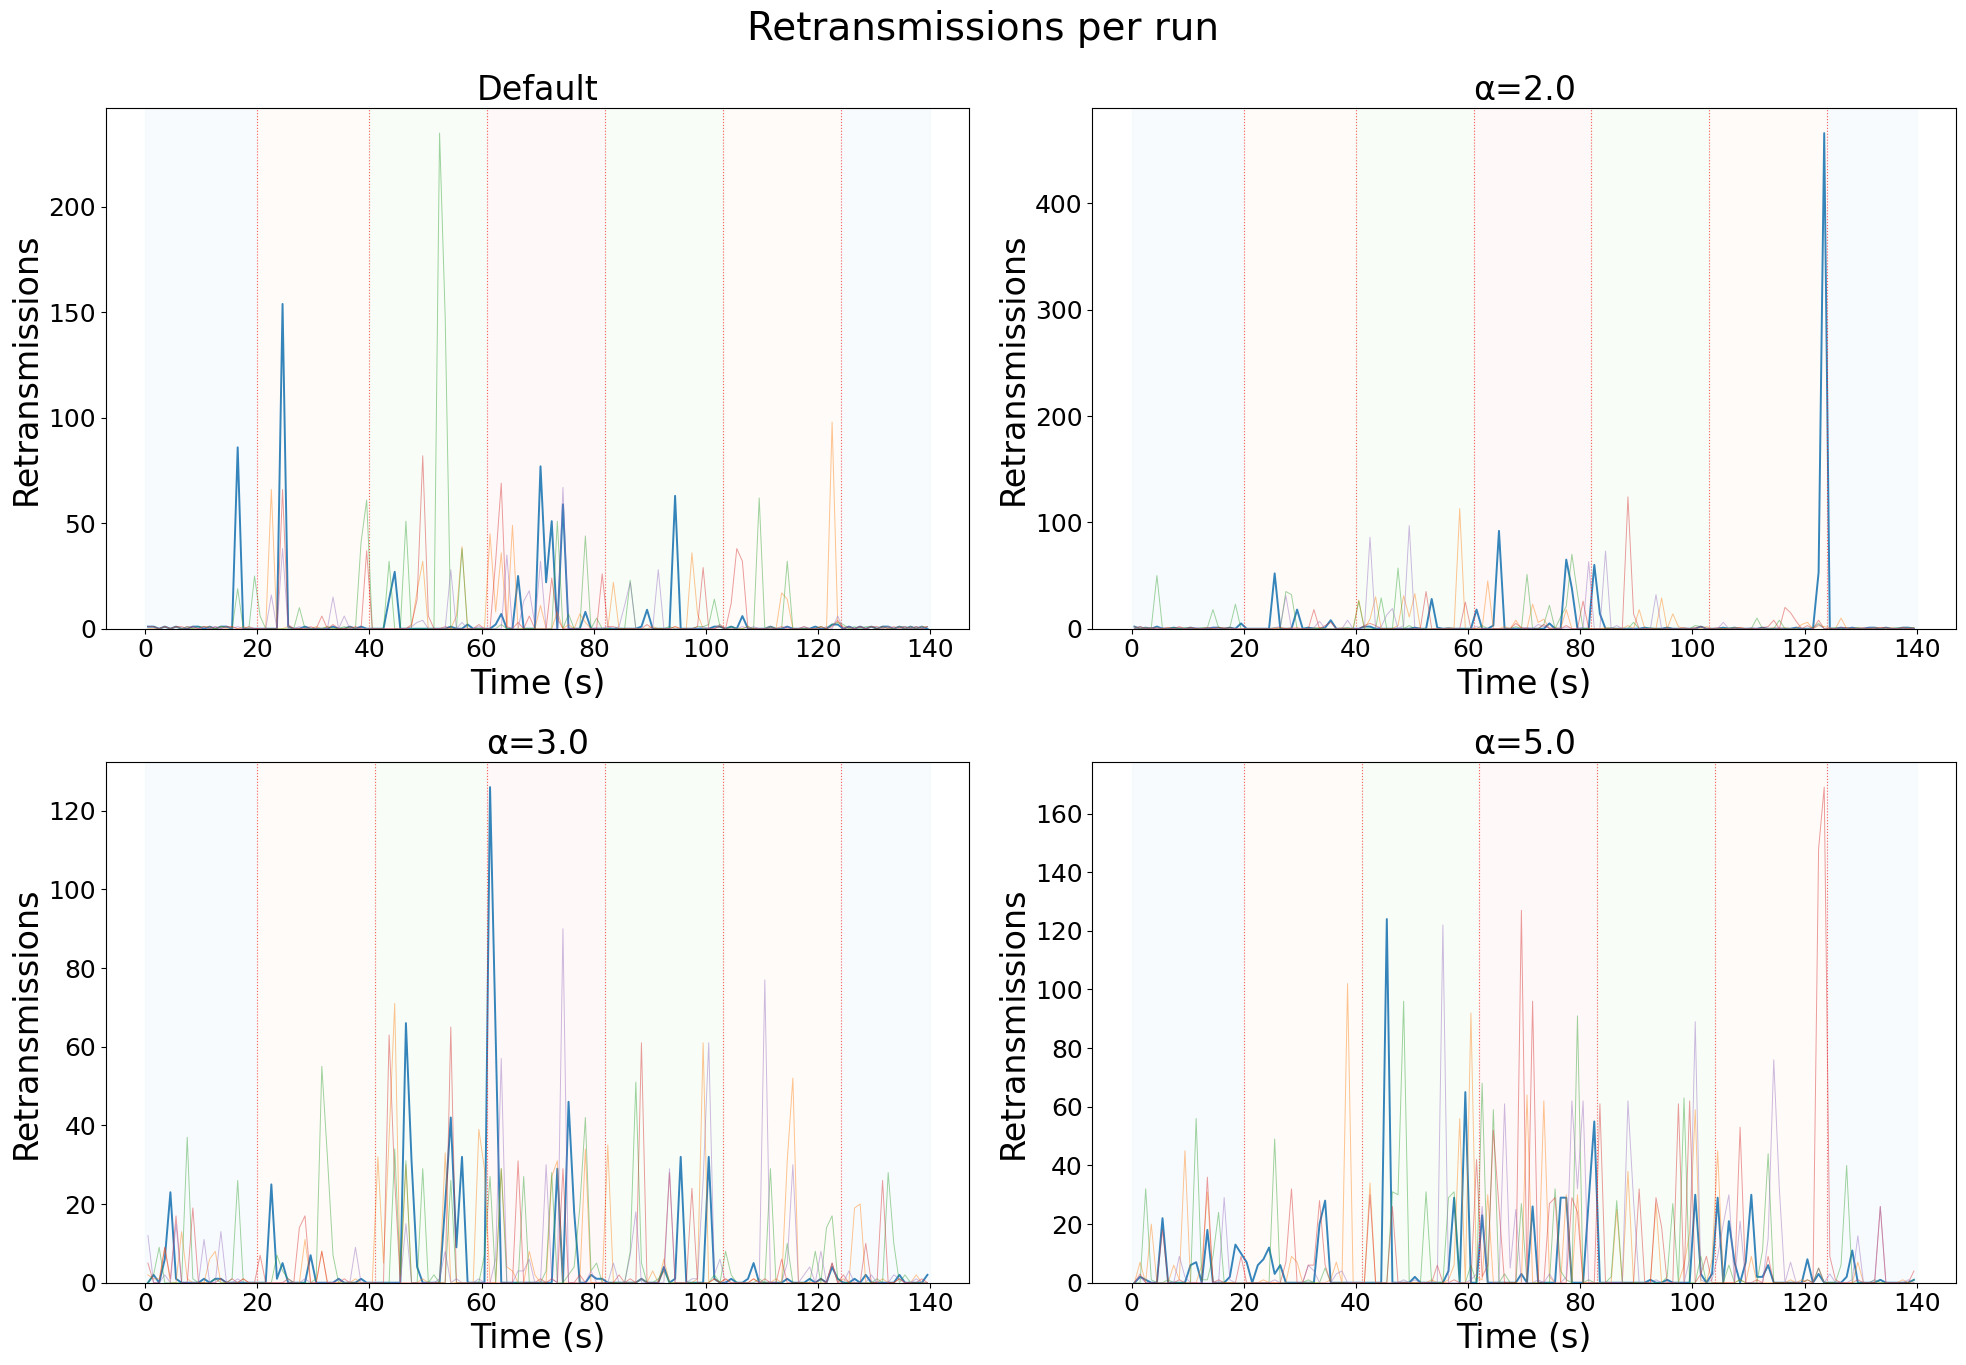

In [8]:
# Throughput per run
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Throughput per run")

for ax, kernel in zip(axes.flat, config.kernels):
    for it in range(1, config.iterations + 1):
        key = (kernel, it)
        if key not in perf_ivals:
            continue
        df = perf_ivals[key]
        ax.plot(df["t_mid"], df["mbps"], linewidth=1.4 if it == 1 else 0.7,
                alpha=0.9 if it == 1 else 0.45)
    key1 = (kernel, 1)
    if key1 in segs_by_key:
        for t_start, t_end, rate_idx in segs_by_key[key1]:
            ax.axvspan(t_start, t_end, color=RATE_COLORS.get(rate_idx, "#f9f9f9"), alpha=0.30, zorder=0)
        for t_start, _, _ in segs_by_key[key1][1:]:
            ax.axvline(t_start, color="red", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.set_title(KERNEL_LABELS[kernel])
    ax.set_ylabel("Mbps")
    ax.set_xlabel("Time (s)")
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(plot_dir / "throughput_per_run.png", dpi=150, bbox_inches="tight")
plt.show()

# RTT per run
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("RTT per run")

for ax, kernel in zip(axes.flat, config.kernels):
    for it in range(1, config.iterations + 1):
        key = (kernel, it)
        if key not in perf_ivals:
            continue
        df = perf_ivals[key]
        ax.plot(df["t_mid"], df["rtt_us"], linewidth=1.4 if it == 1 else 0.7,
                alpha=0.9 if it == 1 else 0.45)
    key1 = (kernel, 1)
    if key1 in segs_by_key:
        for t_start, t_end, rate_idx in segs_by_key[key1]:
            ax.axvspan(t_start, t_end, color=RATE_COLORS.get(rate_idx, "#f9f9f9"), alpha=0.30, zorder=0)
        for t_start, _, _ in segs_by_key[key1][1:]:
            ax.axvline(t_start, color="red", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.set_title(KERNEL_LABELS[kernel])
    ax.set_ylabel("RTT (µs)")
    ax.set_xlabel("Time (s)")
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(plot_dir / "rtt_per_run.png", dpi=150, bbox_inches="tight")
plt.show()

# Retransmissions per run
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Retransmissions per run")

for ax, kernel in zip(axes.flat, config.kernels):
    for it in range(1, config.iterations + 1):
        key = (kernel, it)
        if key not in perf_ivals:
            continue
        df = perf_ivals[key]
        ax.plot(df["t_mid"], df["retransmits"], linewidth=1.4 if it == 1 else 0.7,
                alpha=0.9 if it == 1 else 0.45)
    key1 = (kernel, 1)
    if key1 in segs_by_key:
        for t_start, t_end, rate_idx in segs_by_key[key1]:
            ax.axvspan(t_start, t_end, color=RATE_COLORS.get(rate_idx, "#f9f9f9"), alpha=0.30, zorder=0)
        for t_start, _, _ in segs_by_key[key1][1:]:
            ax.axvline(t_start, color="red", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.set_title(KERNEL_LABELS[kernel])
    ax.set_ylabel("Retransmissions")
    ax.set_xlabel("Time (s)")
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(plot_dir / "retransmissions_per_run.png", dpi=150, bbox_inches="tight")
plt.show()


## Metrics per rate segment

Aggregate iperf3 intervals by rate segment. Bars show mean ± std across iterations.

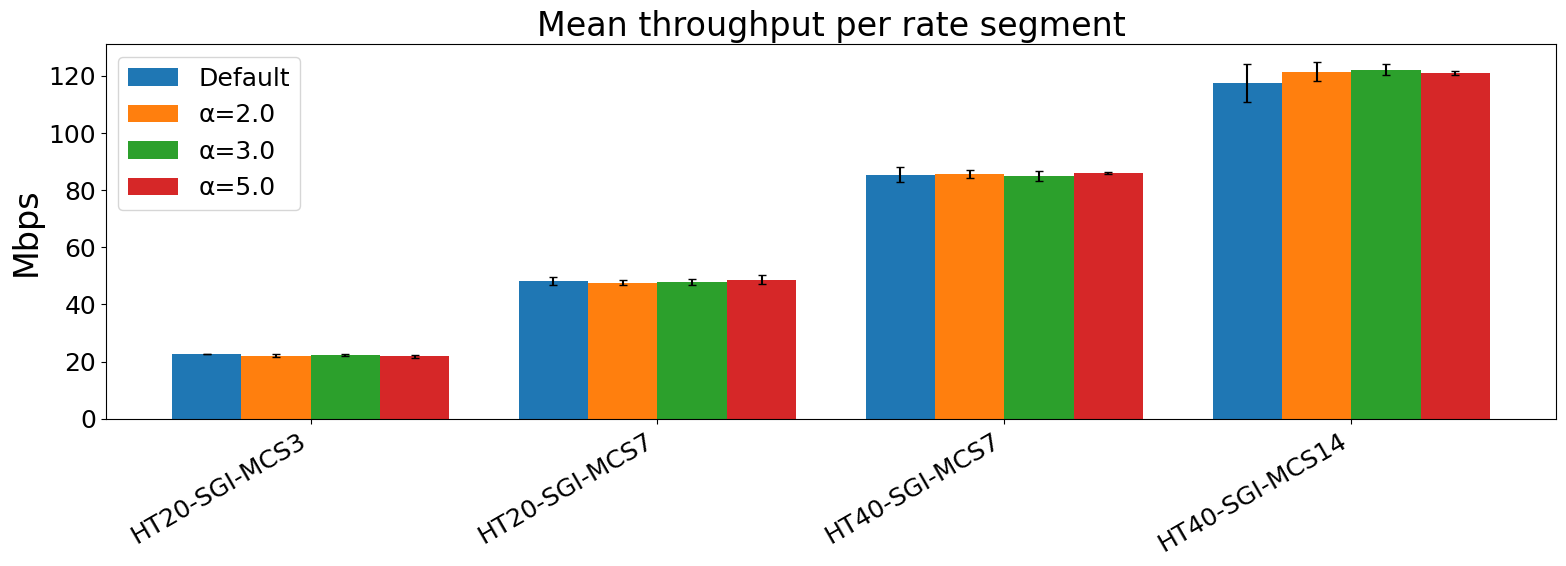

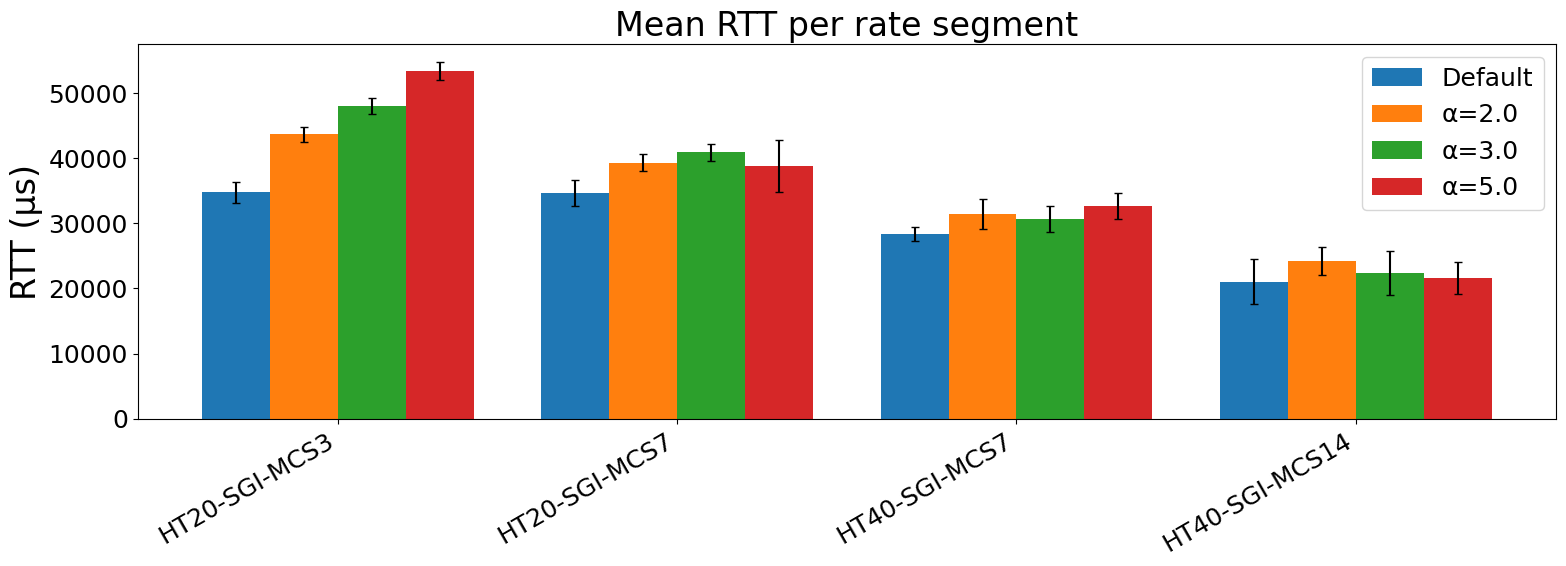

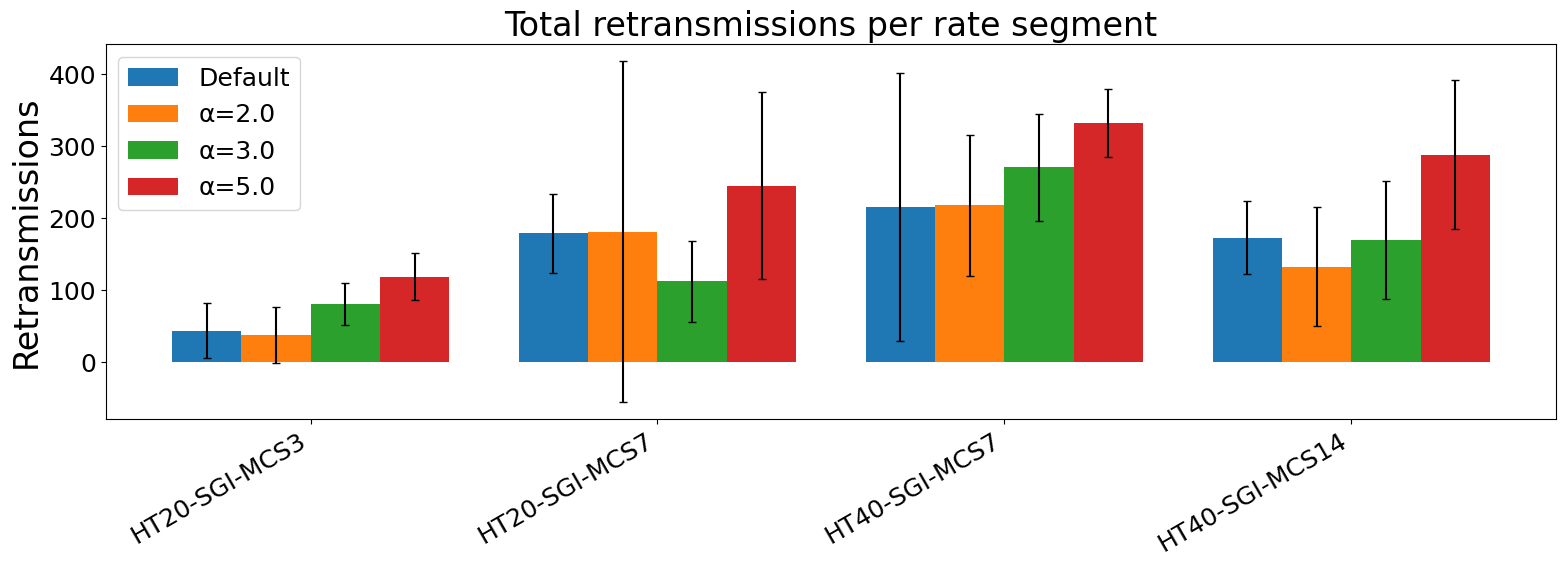

In [9]:
seg_rows = []
for kernel in config.kernels:
    for it in range(1, config.iterations + 1):
        key = (kernel, it)
        if key not in perf_ivals:
            continue
        df = perf_ivals[key].dropna(subset=["rate_idx"])
        for rate_idx, grp in df.groupby("rate_idx"):
            seg_rows.append({
                "kernel": kernel, "rate_idx": int(rate_idx), "iteration": it,
                "mbps": grp["mbps"].mean(), "rtt_us": grp["rtt_us"].mean(),
                "retransmits": grp["retransmits"].sum(),
            })
df_seg = pd.DataFrame(seg_rows)

x = np.arange(len(RATE_ORDER))
n = len(config.kernels)
width = 0.8 / n

# Throughput per segment
fig, ax = plt.subplots(figsize=(16, 6))
for i, kernel in enumerate(config.kernels):
    sub = df_seg[df_seg["kernel"] == kernel]
    stats = sub.groupby("rate_idx")["mbps"].agg(["mean", "std"])
    means = [stats.loc[r, "mean"] if r in stats.index else 0 for r in RATE_ORDER]
    stds  = [stats.loc[r, "std"]  if r in stats.index else 0 for r in RATE_ORDER]
    ax.bar(x + (i - n / 2 + 0.5) * width, means, width, yerr=stds, label=KERNEL_LABELS[kernel], capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(RATE_NAMES, rotation=30, ha="right")
ax.set_ylabel("Mbps")
ax.set_title("Mean throughput per rate segment")
ax.legend()
plt.tight_layout()
plt.savefig(plot_dir / "throughput_per_segment.png", dpi=150, bbox_inches="tight")
plt.show()

# RTT per segment
fig, ax = plt.subplots(figsize=(16, 6))
for i, kernel in enumerate(config.kernels):
    sub = df_seg[df_seg["kernel"] == kernel]
    stats = sub.groupby("rate_idx")["rtt_us"].agg(["mean", "std"])
    means = [stats.loc[r, "mean"] if r in stats.index else 0 for r in RATE_ORDER]
    stds  = [stats.loc[r, "std"]  if r in stats.index else 0 for r in RATE_ORDER]
    ax.bar(x + (i - n / 2 + 0.5) * width, means, width, yerr=stds, label=KERNEL_LABELS[kernel], capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(RATE_NAMES, rotation=30, ha="right")
ax.set_ylabel("RTT (µs)")
ax.set_title("Mean RTT per rate segment")
ax.legend()
plt.tight_layout()
plt.savefig(plot_dir / "rtt_per_segment.png", dpi=150, bbox_inches="tight")
plt.show()

# Retransmissions per segment
fig, ax = plt.subplots(figsize=(16, 6))
for i, kernel in enumerate(config.kernels):
    sub = df_seg[df_seg["kernel"] == kernel]
    stats = sub.groupby("rate_idx")["retransmits"].agg(["mean", "std"])
    means = [stats.loc[r, "mean"] if r in stats.index else 0 for r in RATE_ORDER]
    stds  = [stats.loc[r, "std"]  if r in stats.index else 0 for r in RATE_ORDER]
    ax.bar(x + (i - n / 2 + 0.5) * width, means, width, yerr=stds, label=KERNEL_LABELS[kernel], capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(RATE_NAMES, rotation=30, ha="right")
ax.set_ylabel("Retransmissions")
ax.set_title("Total retransmissions per rate segment")
ax.legend()
plt.tight_layout()
plt.savefig(plot_dir / "retransmissions_per_segment.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
_ITER_HDR = re.compile(r"^--- Iteration (\d+)")
_ACK_COUNT = re.compile(r"ACK count\s*:\s*(\d+)")
_AMPDU_AVG = re.compile(r"Average # of aggregated frames per A-MPDU:\s+([\d.]+)")

ack_rows = []
agg_rows = []
for kernel in config.kernels:
    for it in range(1, config.iterations + 1):
        log_path = config.root / kernel / "logs" / f"ratechange_bwnolim_delaynodelay_iter{it}.log"
        if not log_path.exists():
            continue
        cur_iter = None
        for line in log_path.read_text().splitlines():
            m = _ITER_HDR.search(line)
            if m:
                cur_iter = int(m.group(1))
                continue
            m = _ACK_COUNT.search(line)
            if m and cur_iter is not None:
                ack_rows.append({"kernel": kernel, "iteration": cur_iter, "ack_count": int(m.group(1))})
            m = _AMPDU_AVG.search(line)
            if m and cur_iter is not None:
                agg_rows.append({"kernel": kernel, "iteration": cur_iter, "ampdu_avg": float(m.group(1))})

df_acks = pd.DataFrame(ack_rows)
df_agg  = pd.DataFrame(agg_rows)
print(f"ACK rows: {len(df_acks)}, AMPDU rows: {len(df_agg)}")
if not df_acks.empty:
    print(df_acks.groupby("kernel")["ack_count"].agg(["mean", "std"]).round(0))


ACK rows: 40, AMPDU rows: 180
               mean     std
kernel                     
default    405709.0  6145.0
tcpaad_20   58719.0  6631.0
tcpaad_30   58411.0  2846.0
tcpaad_50   60649.0  6660.0


## Convergence time

For each rate change in the gradual sequence, measure the time from the logged rate change to when `iat_estimate` first reaches within ±20% of the expected value.

In [11]:
CONV_TOL = 0.20

conv_rows = []
for kernel in TCPAAD_KERNELS:
    for it in range(1, config.iterations + 1):
        key = (kernel, it)
        if key not in recv_data or key not in rates_data:
            continue
        df_recv = recv_data[key]
        df_rates = rates_data[key]
        if df_recv.empty or df_rates.empty:
            continue
        main_sk = get_main_sk(df_recv)
        df_main = df_recv[df_recv["sk"] == main_sk].sort_values("ts")
        ref_ts = df_rates["ts"].iloc[0]
        total = perf_ivals[key]["t_end"].max() if key in perf_ivals else 20.0
        segs = rate_segments(df_rates, total)
        for seg_i, (t_start, t_end, new_rate) in enumerate(segs):
            if seg_i == 0:
                continue
            exp = EXPECTED_IAT.get(new_rate)
            if exp is None:
                continue
            lo, hi = exp * (1 - CONV_TOL), exp * (1 + CONV_TOL)
            change_ts = ref_ts + pd.Timedelta(seconds=t_start)
            seg_end_ts = ref_ts + pd.Timedelta(seconds=t_end)
            after_win = df_main[(df_main["ts"] >= change_ts) & (df_main["ts"] <= seg_end_ts)]
            t_conv = None
            for _, r in after_win.iterrows():
                est = r["iat_estimate"]
                if est > 0 and lo <= est <= hi:
                    t_conv = (r["ts"] - change_ts).total_seconds()
                    break
            from_rate = segs[seg_i - 1][2]
            conv_rows.append({
                "kernel": kernel, "iteration": it,
                "from_rate": from_rate, "to_rate": new_rate,
                "transition": f"{config.get_rate_name(from_rate)} → {config.get_rate_name(new_rate)}",
                "conv_s": t_conv,
            })

df_conv = pd.DataFrame(conv_rows)
print(f"Transitions tracked: {len(df_conv)}")
df_conv.head(10)


Transitions tracked: 90


,kernel,iteration,from_rate,to_rate,transition,conv_s
0,tcpaad_20,1,67,71,HT20-SGI-MCS3 → HT20-SGI-MCS7,0.000013
1,tcpaad_20,1,71,199,HT20-SGI-MCS7 → HT40-SGI-MCS7,0.000021
2,tcpaad_20,1,199,214,HT40-SGI-MCS7 → HT40-SGI-MCS14,0.000048
3,tcpaad_20,1,214,199,HT40-SGI-MCS14 → HT40-SGI-MCS7,0.000043
4,tcpaad_20,1,199,71,HT40-SGI-MCS7 → HT20-SGI-MCS7,0.000045
5,tcpaad_20,1,71,67,HT20-SGI-MCS7 → HT20-SGI-MCS3,0.268424
6,tcpaad_20,2,67,71,HT20-SGI-MCS3 → HT20-SGI-MCS7,0.000222
7,tcpaad_20,2,71,199,HT20-SGI-MCS7 → HT40-SGI-MCS7,0.000053
8,tcpaad_20,2,199,214,HT40-SGI-MCS7 → HT40-SGI-MCS14,0.000680
9,tcpaad_20,2,214,199,HT40-SGI-MCS14 → HT40-SGI-MCS7,0.004353


In [12]:
if df_conv.empty:
    print("No convergence data (dmesg not captured)")
else:
    summary = (
        df_conv.dropna(subset=["conv_s"])
        .groupby(["kernel", "from_rate", "to_rate", "transition"])["conv_s"]
        .agg(["median", "min", "max", "count"])
        .round(3)
        .reset_index()
    )
    summary["alpha"] = summary["kernel"].map(KERNEL_LABELS)
    print(summary[["alpha", "transition", "median", "min", "max", "count"]].to_string(index=False))


alpha                     transition  median  min   max  count
α=2.0  HT20-SGI-MCS3 → HT20-SGI-MCS7   0.000  0.0 0.000      5
α=2.0  HT20-SGI-MCS7 → HT20-SGI-MCS3   0.018  0.0 0.620      5
α=2.0  HT20-SGI-MCS7 → HT40-SGI-MCS7   0.000  0.0 0.000      5
α=2.0  HT40-SGI-MCS7 → HT20-SGI-MCS7   0.000  0.0 0.001      5
α=2.0 HT40-SGI-MCS7 → HT40-SGI-MCS14   0.001  0.0 0.002      5
α=2.0 HT40-SGI-MCS14 → HT40-SGI-MCS7   0.001  0.0 0.004      5
α=3.0  HT20-SGI-MCS3 → HT20-SGI-MCS7   0.000  0.0 0.001      5
α=3.0  HT20-SGI-MCS7 → HT20-SGI-MCS3   0.000  0.0 0.001      5
α=3.0  HT20-SGI-MCS7 → HT40-SGI-MCS7   0.000  0.0 0.002      5
α=3.0  HT40-SGI-MCS7 → HT20-SGI-MCS7   0.000  0.0 0.102      5
α=3.0 HT40-SGI-MCS7 → HT40-SGI-MCS14   0.000  0.0 0.001      5
α=3.0 HT40-SGI-MCS14 → HT40-SGI-MCS7   0.000  0.0 0.003      5
α=5.0  HT20-SGI-MCS3 → HT20-SGI-MCS7   0.000  0.0 0.007      5
α=5.0  HT20-SGI-MCS7 → HT20-SGI-MCS3   0.026  0.0 0.088      5
α=5.0  HT20-SGI-MCS7 → HT40-SGI-MCS7   0.002  0.0 0.004

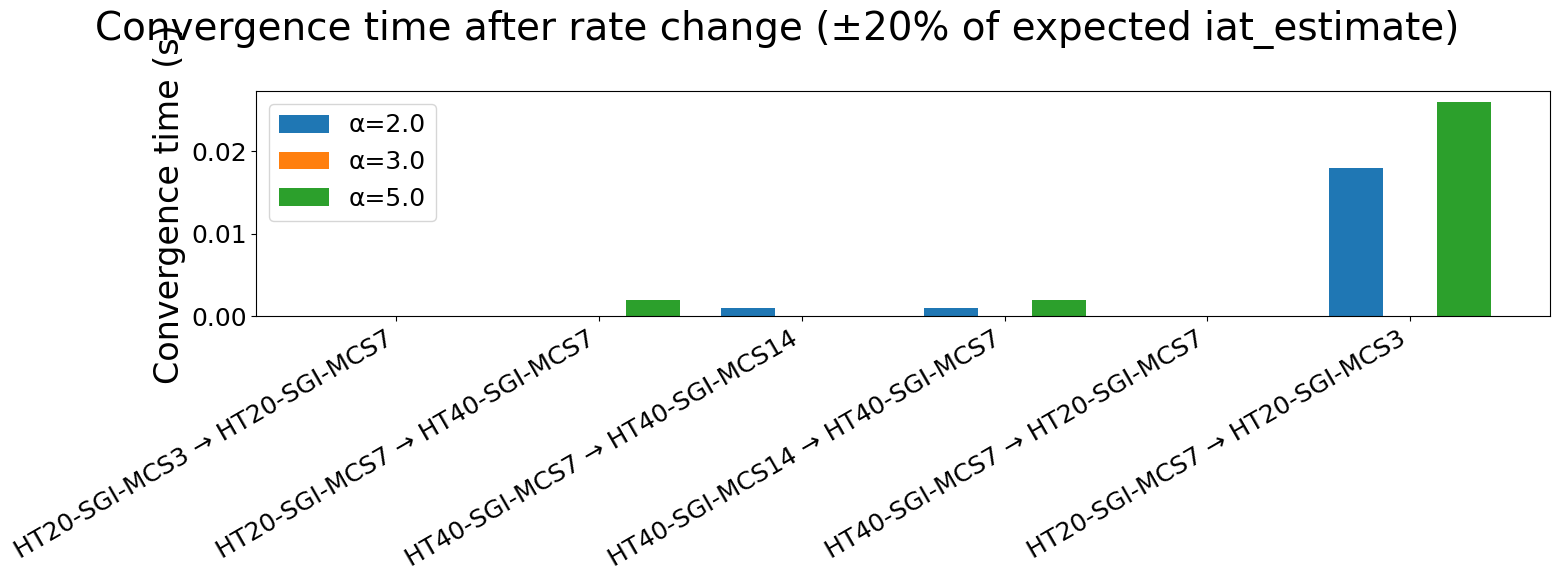

In [13]:
if not df_conv.empty:
    transitions = df_conv["transition"].unique()
    x = np.arange(len(transitions))
    n = len(TCPAAD_KERNELS)
    width = 0.8 / n
    
    fig, ax = plt.subplots(figsize=(16, 6))
    fig.suptitle("Convergence time after rate change (±20% of expected iat_estimate)")
    
    for j, kernel in enumerate(TCPAAD_KERNELS):
        ksub = summary[summary["kernel"] == kernel].set_index("transition")
        ys = [ksub.loc[t, "median"] if t in ksub.index else np.nan for t in transitions]
        ax.bar(x + (j - n / 2 + 0.5) * width, ys, width, label=KERNEL_LABELS[kernel])
    
    ax.set_xticks(x)
    ax.set_xticklabels(transitions, rotation=30, ha="right")
    ax.set_ylabel("Convergence time (s)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / "convergence_time.png", dpi=150, bbox_inches="tight")
    plt.show()


## Zoomed view: single rate change

±2 s window around each rate change, all α values overlaid.

In [14]:
def plot_zoomed_transition(from_rate, to_rate, iteration=1, window_s=2.0):
    fig, ax = plt.subplots(figsize=(12, 5))
    for kernel in TCPAAD_KERNELS:
        key = (kernel, iteration)
        if key not in recv_data or key not in rates_data:
            continue
        df_recv = recv_data[key]
        df_rates = rates_data[key]
        if df_recv.empty or df_rates.empty:
            continue
        main_sk = get_main_sk(df_recv)
        df_main = df_recv[df_recv["sk"] == main_sk].sort_values("ts")
        match = df_rates[(df_rates["rate_idx"] == to_rate) & (~df_rates["is_initial"])]
        if match.empty:
            continue
        t_event = match["ts"].iloc[0]
        t_lo = t_event.timestamp() - window_s
        t_hi = t_event.timestamp() + window_s
        mask = df_main["ts"].apply(lambda t: t_lo <= t.timestamp() <= t_hi)
        df_win = df_main[mask].copy()
        if df_win.empty:
            continue
        df_win["t_rel"] = df_win["ts"].apply(lambda t: t.timestamp() - t_event.timestamp())
        df_win = downsample_by_change(df_win)
        ax.step(df_win["t_rel"], df_win["iat_estimate"], where="post",
                linewidth=1.5, label=KERNEL_LABELS[kernel])
    for rate, side in [(from_rate, "left"), (to_rate, "right")]:
        exp = EXPECTED_IAT.get(rate, 0)
        xlo, xhi = (-window_s, 0) if side == "left" else (0, window_s)
        ax.hlines(exp, xlo, xhi, colors="#555", linewidths=1.2, linestyles="--", zorder=2)
        ax.text((xlo + xhi) / 2, exp * 1.12, f"{config.get_rate_name(rate)} exp={exp}µs",
                ha="center", fontsize=11, color="#333")
        ax.axvspan(xlo, xhi, alpha=0.10, color=RATE_COLORS.get(rate, "#f9f9f9"), zorder=0)
    ax.axvline(0, color="red", linewidth=1.5, linestyle=":", label="rate change")
    ax.set_xlabel("Time relative to rate change (s)")
    ax.set_ylabel("iat_estimate (µs)")
    ax.set_title(f"Convergence: {config.get_rate_name(from_rate)} → {config.get_rate_name(to_rate)}  (iter {iteration})")
    ax.legend()
    ax.set_xlim(-window_s, window_s)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    return fig


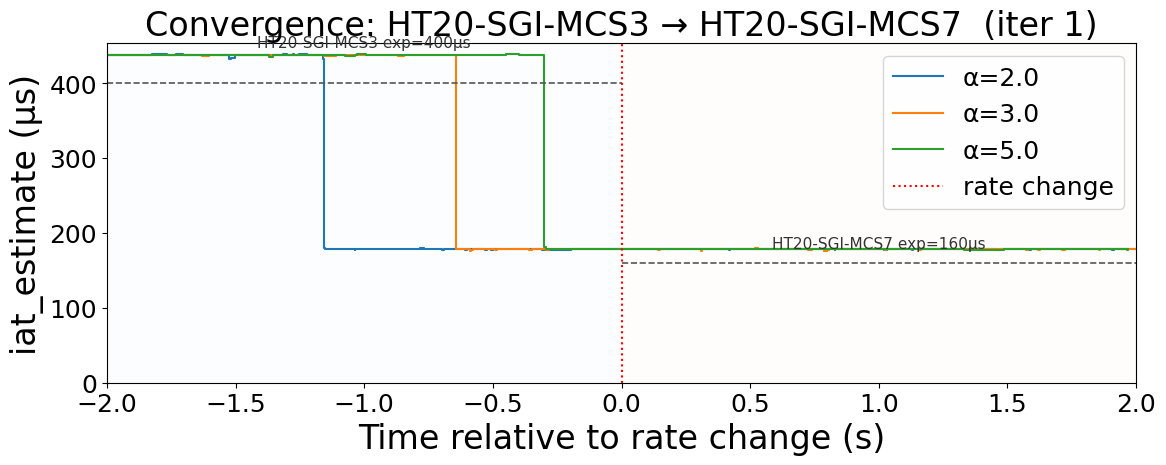

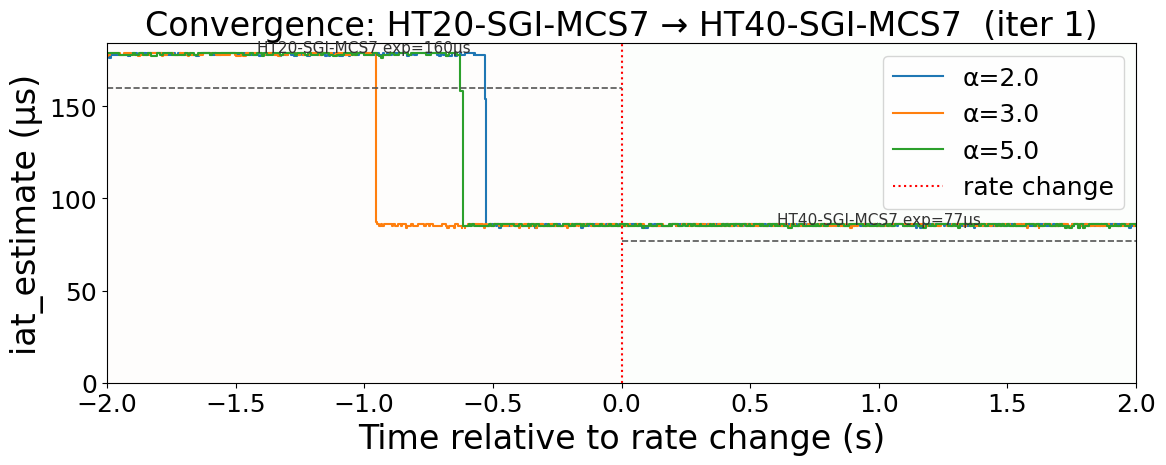

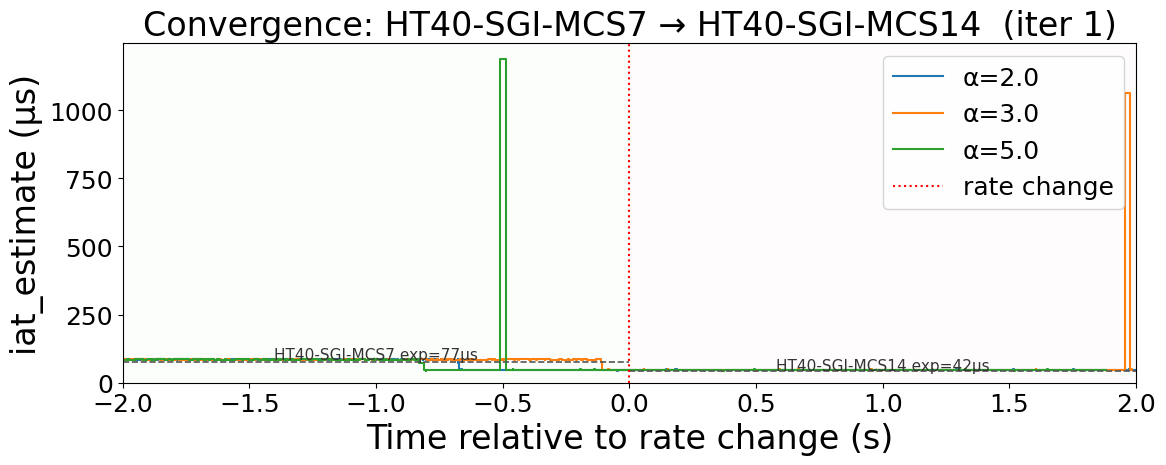

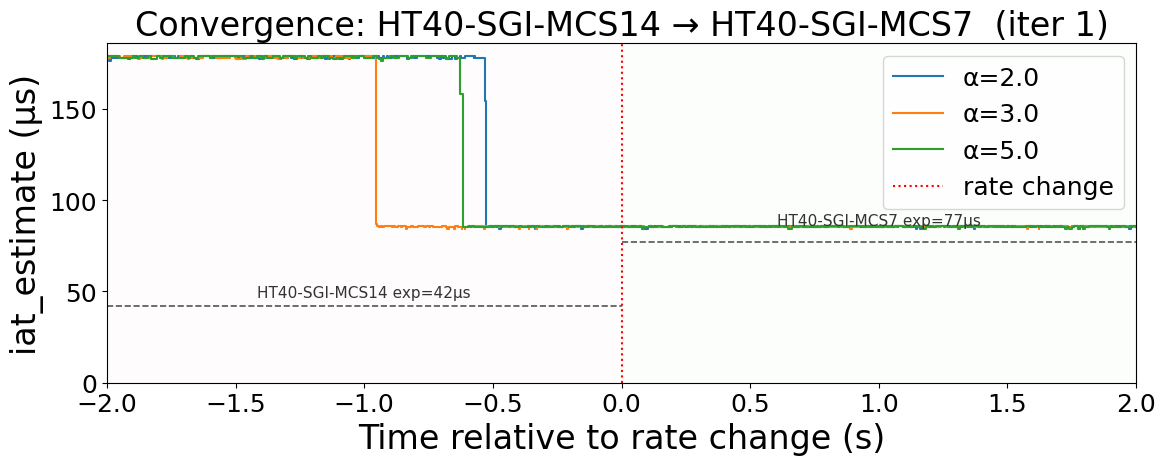

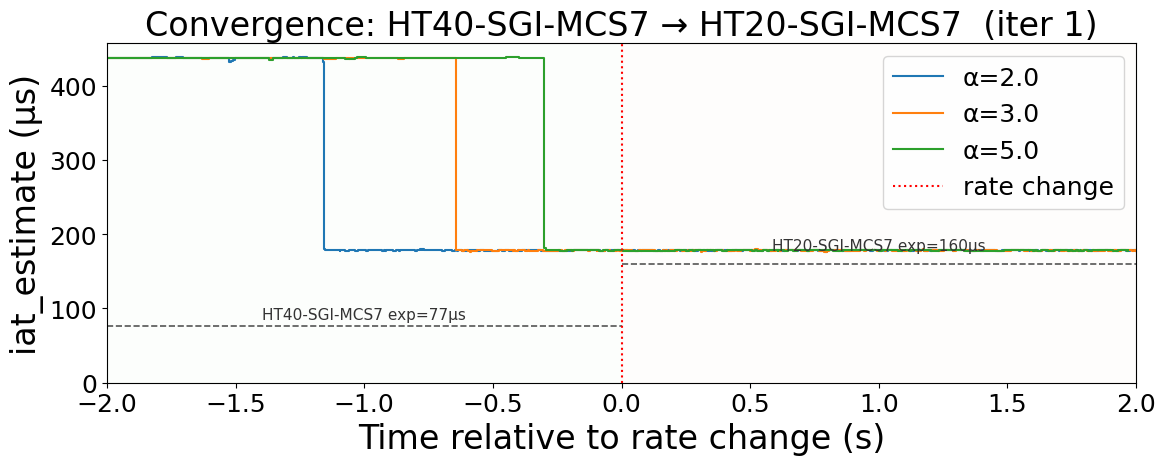

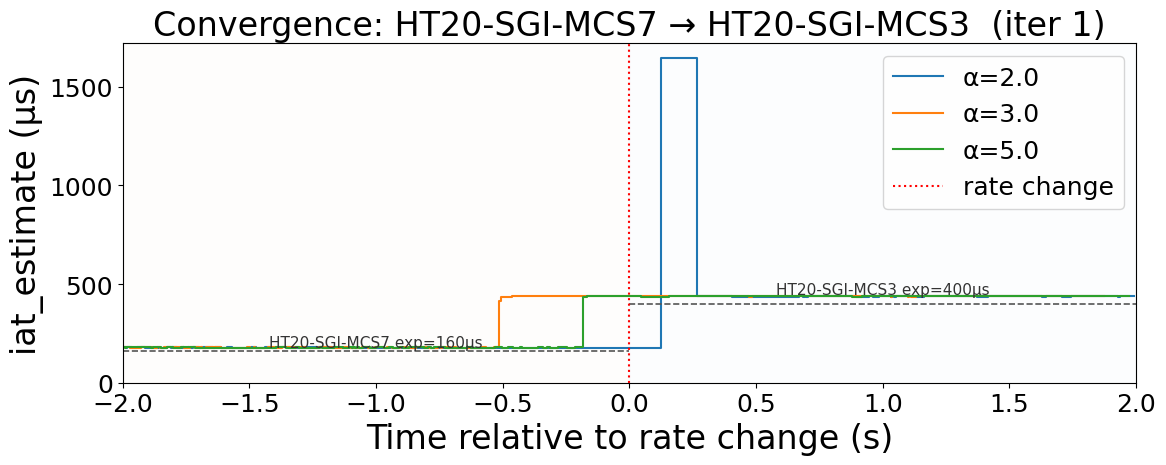

In [15]:
for fr, to in [(67, 71), (71, 199), (199, 214), (214, 199), (199, 71), (71, 67)]:
    fig = plot_zoomed_transition(fr, to, iteration=1)
    plt.savefig(plot_dir / f"zoom_{fr}_{to}.png", dpi=150, bbox_inches="tight")
    plt.show()
